### Clase 07: Regresion logistica

Denominado como clasificacion binaria.
- Con esta regresion puedo responder por ejemplo si/no; true/false. 
- Determina a que categoria pertenece el dato en si.
- Utiliza una funcion sigmoide que lo que hace es que todos los valores se ubican en un rango entre  0-1 .
- Es decir el algoritmo devuelve una probabilidad (0-100%) que un evento ocurra 
- Tiene un umbral de corte de default de la probabilidad. Por ejemplo si el rango va de 0-100, hasta 50 es si y 51-100 es NO. Pero se puede cambiar manualmente
- Principal diferencia con la RL es la pregunta que intenta responder:
    - RL==> Cuanto? /// Logistica: SI/NO?

In [10]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
print ("librerias ok")

librerias ok


In [11]:
#Se descargo el dataset en la clase anterior
# El link se saca de lo que me dice kaggle antes
df_test = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Test.csv")
df_train = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Train.csv")
#Unimos los dos dataset
df_concat = pd.concat([df_train, df_test], ignore_index=True)
#Verificamos
print(f"Hay {len(df_test)} registros en test")
print(f"Hay {len(df_train)} registros en train")
print(f"Hay {len(df_concat)} registros en total")

Hay 418 registros en test
Hay 891 registros en train
Hay 1309 registros en total


In [12]:
# Objetivo del proyecto: Predecir si sobrevivieron o no
#Hacemos una copia del df para no trabajar sobre la original
df = df_concat.copy()
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 122.8 KB


- Tenemos que ver cuales son las variables que vamos a utilizar en el modelo.
- Se ve que hay algunas que son numericas y otras que son string como el Sexo.
- Esta la vamos a tener que trnsformar para que sean valores unitarios

In [14]:
# Hago un encoding para que sean valores unitarios
df['Sex_encoded'] = df['Sex'].map ({"male":0, "female":1})

#Tomo solo algunas columnas segun el objetivo del proyecto
columas = ['Survived', 'Pclass',  'Sex_encoded', 'Age', 'SibSp', 'Parch']
df = df[columas].dropna()

#Variables que voy a usar para predecir el precio del pasaje
X = df[['Pclass',  'Sex_encoded', 'Age', 'SibSp', 'Parch']]

#Variable objetivo
Y = df [['Survived']] 

#Cantidad de registros
print(f"Quedaron {len(df)} pasajeros para el entrenamiento del modelo")

Quedaron 714 pasajeros para el entrenamiento del modelo


In [15]:
# Generamos el datset para entrenamiento y testeo
# Entrenamiento 80% - 20% testeo
# random_state, es una semilla aleatorio
X_Train,X_Test, Y_Train,Y_Test = train_test_split(X,Y, test_size=0.2, random_state=42)

#Veo la longitud de cada uno de los dataset
print(f"Datos para entrenar {X_Train.shape[0]} pasajeros")
print(f"Datos para testear {X_Test.shape[0]} pasajeros")

#Se podria haber trabajado directamente como estaba el dataset en el kaggle (train/test)

Datos para entrenar 571 pasajeros
Datos para testear 143 pasajeros


In [16]:
#Construccion del modelo de regresion logistica
modelo = LogisticRegression ()
#Entrenamiento con las variables seleccionadas (X) y la variable ojetivo (Y)
modelo.fit (X_Train, Y_Train)

d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
#Mostramos los coeficientes del modelo generado para cada variable
coeficientes_modelo = pd.DataFrame({"Pista variables": X.columns, "Coeficientes": modelo.coef_[0]})
print(coeficientes_modelo)

  Pista variables  Coeficientes
0          Pclass     -1.280119
1     Sex_encoded      2.611885
2             Age     -0.048807
3           SibSp     -0.338201
4           Parch     -0.031116


Estos coeficites nos dicen:
- Sexo y la clase son las variables que mas influyen en la supervivencia de las personas
- En el sexo indica que ser mujer aumenta fuertemente la probabilidad de supervivencia.
- Clase: A medida que aumenta el número de clase, disminuye la probabilidad de sobrevivir.
- El resto de las variables no son tan influyentes
- En relacion a estos resultados nos muestran que:
- Age: A mayor edad, ligeramente menor probabilidad de sobrevivir.
- SibSp1 (relacion familiar, hermanos/conyuges): Viajar con más hermanos o cónyuges se asoció con una menor probabilidad de supervivencia.
- Parch (madre/padre/hijos): El efecto es muy pequeño, lo que muestra prácticamente no influye en el modelo.

In [18]:
#Se hace la prediccion
y_pred = modelo.predict(X_Test)

En una regresión logística, los coeficientes no representan cambios directos en la variable respuesta, sino cambios en el logaritmo de las odds.
Es decir la comparativa entre que ocurre/no ocurra un evento
Regla práctica:
(1 verdadero, 0 falso)
- Coeficiente positivo → aumenta la probabilidad de pertenecer a la clase 1.
- Coeficiente negativo → disminuye la probabilidad de pertenecer a la clase 1.
Cuanto mayor sea el valor absoluto, mayor es la influencia.

#### Matriz de confusion


Por default tengo un umbral del 50%, si tiene mas del 50% de prediccion lo va a tomar como *SI*, si esta por debajo del 50% lo toma como *NO*

In [19]:
# Hacemos matriz de confusion
acc = accuracy_score (Y_Test, y_pred)
cm = confusion_matrix (Y_Test, y_pred)

print(f"Presicion Global (Accuracy): {acc*100:.2f}% de aciertos ")
print(cm)

Presicion Global (Accuracy): 76.22% de aciertos 
[[71 16]
 [18 38]]


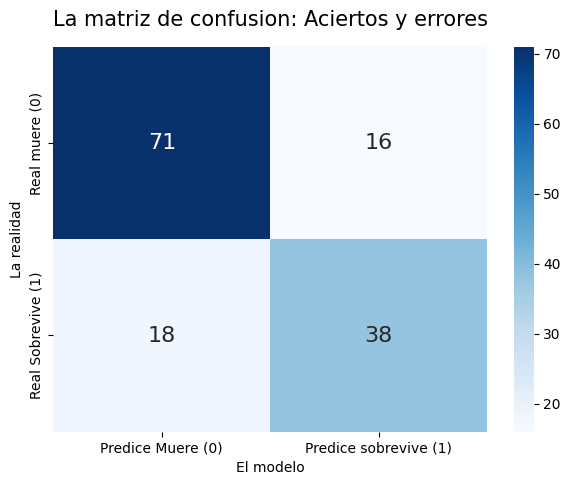

In [20]:
#Generacion de matrriz para una mejor visualizacion
plt.figure(figsize = (7,5))
sns.heatmap(cm, annot =True, fmt ="d", cmap ="Blues", annot_kws = {"size": 16},
            xticklabels = ["Predice Muere (0)", "Predice sobrevive (1)"],
            yticklabels= ["Real muere (0)", "Real Sobrevive (1)"])

plt.title ("La matriz de confusion: Aciertos y errores", fontsize =15, pad=15)
plt.ylabel("La realidad")
plt.xlabel ("El modelo")
plt.show()


#### Resumen
- TN (True Negatives) = 71 ==> El pasajero no sobrevivió y el modelo predijo correctamente que no sobreviviría.
- FP (False Positives) = 16 ==> El pasajero no sobrevivió, pero el modelo predijo que sí sobreviviría.
- FN (False Negatives) = 18 ==> El pasajero sobrevivió, pero el modelo predijo que no sobreviviría.
- TP (True Positives) = 38 ==> El pasajero sobrevivió y el modelo lo predijo correctamente.

In [21]:
# evaluar el desempeño de tu modelo de clasificación de forma más completa que usando solamente la accuracy.
print("Reporte detallado")
print(classification_report(Y_Test, y_pred))

Reporte detallado
              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81        87
         1.0       0.70      0.68      0.69        56

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



#### Resumen de metricas
- Precision (Accuracy): % total de aciertos del modelo
- Recall (Sensibilidad): Capacidad para detectar correctamente los casos positivos
- F1 score: Equilibrio entre precision y sensibilidad
- Matriz de confusion: Visualizacion detallada de aciertos y errores

### Cambiar sensibilidad del modelo

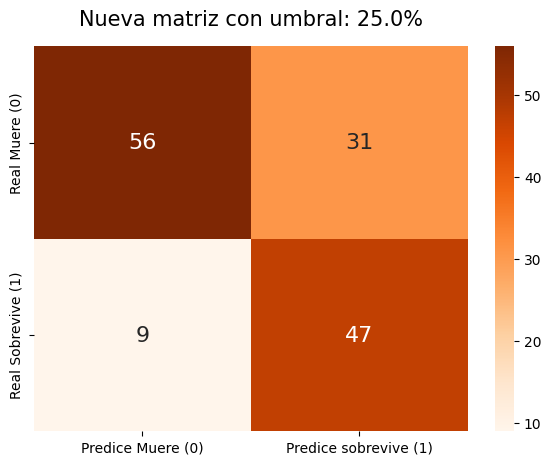

In [ ]:

## Otro ejemplo para cambiar lo que viene por defalta +50%:SI ///-50%NO

#1. Le pedimos que nos de los % de probabilidd
probabilidades = modelo.predict_proba(X_Test)[:,1] #Probabilidad que de 1==> que sobreviva

#Definir umbral propio
# Super sensible: si solo hay 25% de chances que sobreviva decimos que si
umbral_nuevo = 0.25

#Aplicacion nuevo umbral
y_pred_sensible = (probabilidades >= umbral_nuevo).astype(int)

#Compramos como cambio la matriz
cm_sensible = confusion_matrix(Y_Test, y_pred_sensible)

##Hacemos plot
plt.figure (figsize=(7,5))

sns.heatmap(cm_sensible, annot=True, fmt="d", cmap="Oranges", annot_kws ={"size":16},
            xticklabels= ["Predice Muere (0)", "Predice sobrevive (1)"],
            yticklabels= ["Real Muere (0)", "Real Sobrevive (1)"])

plt.title (f"Nueva matriz con umbral: {umbral_nuevo*100}%", fontsize =15, pad=15)
plt.show()

### Evaluaamos que paso


9 son lo que yo dije que sobrevivian y murieron

In [16]:
# evaluar el desempeño de tu modelo de clasificación de forma más completa que usando solamente la accuracy.
print("Reporte detallado")
print(classification_report(Y_Test, y_pred_sensible))

Reporte detallado
              precision    recall  f1-score   support

         0.0       0.86      0.64      0.74        87
         1.0       0.60      0.84      0.70        56

    accuracy                           0.72       143
   macro avg       0.73      0.74      0.72       143
weighted avg       0.76      0.72      0.72       143

